Epoch 0, Loss: 1.0779e-01, Res: 1.87e-03, Fourier: 1.06e-01
Epoch 500, Loss: 1.2794e-04, Res: 7.17e-05, Fourier: 5.63e-05
Epoch 1000, Loss: 6.1911e-05, Res: 4.39e-05, Fourier: 1.80e-05
Epoch 1500, Loss: 5.0680e-05, Res: 2.71e-05, Fourier: 2.36e-05


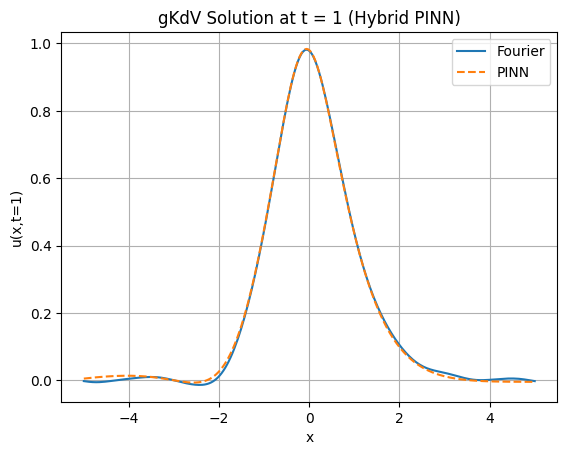

Relative L2 error at t = 1: 1.9513e-02


In [12]:
# ============================================
# HÍBRIDO 1: PINN + Supervisión por Solución Espectral
# ============================================
import torch
import torch.nn as nn
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

# Configuración del dominio
L = 5.0
N = 256
dt = 0.0005
t_max = 1.0
nt = int(t_max / dt)
x = np.linspace(-L, L, N, endpoint=False)
t_vals = np.linspace(0, t_max, nt + 1)

# Parámetros PDE
alpha, nu, gamma = 1.0, 3.0, 0.1

# Condición inicial sin ruido
u0 = 1 / np.cosh(x) ** 2

# Solver espectral
k = fftfreq(N, d=(x[1] - x[0])) * 2 * np.pi
ik3 = (1j * k) ** 3
u = u0.copy()
u_spectral = [u0.copy()]
for _ in range(nt):
    u_hat = fft(u)
    u_disp = np.real(ifft(u_hat * np.exp(-ik3 * gamma * dt)))
    u = u_disp - dt * alpha * u_disp ** nu * np.gradient(u_disp, x[1] - x[0])
    u_spectral.append(u.copy())
u_spectral = np.array(u_spectral)

# Interpolador
interp = RegularGridInterpolator((t_vals, x), u_spectral, method='linear', bounds_error=False, fill_value=None)
def u_fourier_interp(x_input, t_input):
    pts = np.stack([t_input.flatten(), x_input.flatten()], axis=-1)
    return interp(pts)

# Red PINN
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            *[nn.Linear(layers[i], layers[i + 1]) if i == len(layers) - 2 else
              nn.Sequential(nn.Linear(layers[i], layers[i + 1]), nn.Tanh())
              for i in range(len(layers) - 1)]
        )
    def forward(self, x, t):
        return self.net(torch.cat((x, t), dim=1))

def gkdv_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    u = model(x, t)
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x, torch.ones_like(u), retain_graph=True, create_graph=True)[0]
    return u_t + alpha * u**nu * u_x + gamma * u_xxx

# Entrenamiento
model = PINN([2, 50, 50, 50, 1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(2000):
    optimizer.zero_grad()
    x_coll = torch.tensor(np.random.uniform(-L, L, (1000, 1)), dtype=torch.float32)
    t_coll = torch.tensor(np.random.uniform(0, t_max, (1000, 1)), dtype=torch.float32)

    res = gkdv_residual(model, x_coll, t_coll)
    loss_res = torch.mean(res**2)

    u_fourier = torch.tensor(u_fourier_interp(x_coll.detach().numpy(), t_coll.detach().numpy()), dtype=torch.float32).reshape(-1, 1)
    u_pred = model(x_coll, t_coll)
    loss_fourier = torch.mean((u_pred - u_fourier)**2)

    loss = loss_res + loss_fourier
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}, Res: {loss_res.item():.2e}, Fourier: {loss_fourier.item():.2e}")

# Visualización
x_plot = torch.linspace(-L, L, N).reshape(-1, 1)
t_plot = torch.full_like(x_plot, 1.0)
u_pinn = model(x_plot, t_plot).detach().numpy().flatten()
u_true = u_fourier_interp(x_plot.numpy().flatten(), np.full_like(x_plot.numpy().flatten(), 1.0))

plt.plot(x_plot.numpy(), u_true, label='Fourier')
plt.plot(x_plot.numpy(), u_pinn, '--', label='PINN')
plt.legend()
plt.title('gKdV Solution at t = 1 (Hybrid PINN)')
plt.xlabel('x')
plt.ylabel('u(x,t=1)')
plt.grid(True)
plt.show()

# Error relativo L2
rel_L2 = np.sqrt(np.sum((u_pinn - u_true) ** 2) / np.sum(u_true ** 2))
print(f"Relative L2 error at t = 1: {rel_L2:.4e}")
